# Week 5 — Multiple Machine Learning Models
## AI-Based Chocolate Paan Sales Prediction System Using Machine Learning

---

## 1. Objective

The primary objective of **Week 5** is to transition from single-model evaluation to a **multi-model benchmarking study** for predicting chocolate paan sales. Specifically:
1. Implement five diverse machine learning regression algorithms on the same dataset.
2. Maintain strict experimental consistency by using identical train-test splits (`test_size=0.20`, `random_state=42`).
3. Apply appropriate data preprocessing, including feature scaling exclusively where required (e.g., Support Vector Regression), while strictly preventing **data leakage**.
4. Evaluate and compare all models using standard regression metrics:
   - **MAE** (Mean Absolute Error)
   - **MSE** (Mean Squared Error)
   - **RMSE** (Root Mean Squared Error)
   - **R² Score** (Coefficient of Determination)
5. Analyze training versus testing performance to diagnose **overfitting**, **underfitting**, and **generalization capability**.
6. Interpret model mechanics via **Linear Regression Coefficients** and **Random Forest Feature Importances**.
7. Select the most suitable candidate model based on empirical test set performance to inform deployment.

---

## 2. Problem Statement

In this project, our goal is to predict the daily quantity of chocolate paan boxes sold (`Boxes_Sold`) by a retail outlet given environmental, pricing, promotional, operational, and customer engagement features.

### Why is this a Regression Problem?
* In machine learning, problems are broadly divided into **Classification** and **Regression**.
* **Classification** predicts discrete categorical class labels (e.g., `Spam / Not Spam`, `High / Medium / Low`).
* **Regression** predicts a **continuous numerical target variable** on a real-valued number scale.
* Because the target variable `Boxes_Sold` is an integer quantity that can take any positive continuous value depending on business conditions, this is strictly a **Supervised Regression Problem**.

### Business Value:
Accurate sales predictions allow the shop management to optimize fresh ingredient procurement (paan leaves, chocolate sauces, dry fruits), minimize daily stock wastage, dynamically schedule staff, and maximize promotional return on investment (ROI).

---

## 3. Dataset Loading

We load the complete project dataset `Chocolate_Paan_Sales_Dataset_10000.xlsx` containing 10,000 historical daily records.

We import the foundational scientific libraries:
* `pandas` for data manipulation and tabular analysis
* `numpy` for high-performance numerical operations
* `matplotlib.pyplot` and `seaborn` for clear data visualization
* `sklearn` for model training, preprocessing, and performance evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for all charts
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 110

# Load dataset
dataset_path = 'Chocolate_Paan_Sales_Dataset_10000.xlsx'
df = pd.read_excel(dataset_path)

print(f"Dataset successfully loaded from: {dataset_path}")
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Dataset successfully loaded from: Chocolate_Paan_Sales_Dataset_10000.xlsx
Dataset Shape: 10000 rows and 20 columns


,Date,Day_of_Week,Month,Weekend,Festival,Season,Temperature,Rainfall,Price,Discount_Percentage,Instagram_Reel,YouTube_Video,Facebook_Ads,Marketing_Budget,Returning_Customers,New_Customers,Online_Orders,Offline_Orders,Customer_Rating,Boxes_Sold
0,2024-01-01,Monday,1,0,0,Winter,28.3,10.0,120,0,1,0,1,3175,119,51,22,102,4.2,160
1,2024-01-02,Tuesday,1,0,0,Winter,24.0,16.9,100,10,0,1,1,2565,80,34,33,37,4.5,172
2,2024-01-03,Wednesday,1,0,0,Winter,24.9,17.8,110,10,1,0,0,3972,105,58,79,36,4.7,181
3,2024-01-04,Thursday,1,0,1,Winter,24.0,13.8,140,15,1,0,0,1212,116,43,45,102,4.3,237
4,2024-01-05,Friday,1,0,0,Winter,20.5,2.8,110,10,1,1,0,1357,14,44,65,110,3.8,170


---

## 4. Data Understanding

Before splitting and modeling, we inspect:
* Column names and data types
* Summary statistics across numerical features
* Explicit verification of missing (null) values

In [2]:
# Column names and non-null types
print("=== DATASET INFORMATION ===")
df.info()

=== DATASET INFORMATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10000 non-null  object 
 1   Day_of_Week          10000 non-null  object 
 2   Month                10000 non-null  int64  
 3   Weekend              10000 non-null  int64  
 4   Festival             10000 non-null  int64  
 5   Season               10000 non-null  object 
 6   Temperature          10000 non-null  float64
 7   Rainfall             10000 non-null  float64
 8   Price                10000 non-null  int64  
 9   Discount_Percentage  10000 non-null  int64  
 10  Instagram_Reel       10000 non-null  int64  
 11  YouTube_Video        10000 non-null  int64  
 12  Facebook_Ads         10000 non-null  int64  
 13  Marketing_Budget     10000 non-null  int64  
 14  Returning_Customers  10000 non-null  int64  
 15  New_Custo

In [3]:
# Statistical summary of numerical variables
print("=== DESCRIPTIVE STATISTICS ===")
df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].round(2)

=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,50%,max
Month,10000.0,6.46,3.45,1.0,6.0,12.0
Weekend,10000.0,0.28,0.45,0.0,0.0,1.0
Festival,10000.0,0.07,0.26,0.0,0.0,1.0
Temperature,10000.0,28.81,5.64,18.0,28.7,40.0
Rainfall,10000.0,35.09,50.81,0.0,13.4,200.0
Price,10000.0,119.99,14.13,100.0,120.0,140.0
Discount_Percentage,10000.0,10.04,7.05,0.0,10.0,20.0
Instagram_Reel,10000.0,0.49,0.50,0.0,0.0,1.0
YouTube_Video,10000.0,0.50,0.50,0.0,1.0,1.0
Facebook_Ads,10000.0,0.50,0.50,0.0,0.0,1.0


In [4]:
# Check for missing values
print("=== MISSING VALUE VERIFICATION ===")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "Zero missing values detected across all 20 columns!")

=== MISSING VALUE VERIFICATION ===
Zero missing values detected across all 20 columns!


---

## 5. Feature and Target Selection

We separate our dataset into:
* **Feature Matrix ($X$)**: The 14 predictive features capturing weather, pricing, marketing campaigns, customer footfall, orders, ratings, and calendar factors.
* **Target Vector ($Y$)**: The actual ground truth sales quantity (`Boxes_Sold`).

The 14 features used are:
1. `Temperature`: Ambient daily temperature (°C)
2. `Price`: Selling price per box (INR)
3. `Discount_Percentage`: Discount offered (%)
4. `Marketing_Budget`: Daily marketing spend
5. `Instagram_Reel`: Number of Instagram reels posted
6. `YouTube_Video`: Number of promotional YouTube videos released
7. `Facebook_Ads`: Number of active Facebook ad campaigns
8. `Returning_Customers`: Count of repeat visitors
9. `New_Customers`: Count of first-time buyers
10. `Online_Orders`: Volume of delivery orders
11. `Offline_Orders`: Volume of walk-in store orders
12. `Customer_Rating`: Average customer satisfaction score (1.0 to 5.0)
13. `Festival`: Binary flag (1 = Festival day, 0 = Non-festival day)
14. `Weekend`: Binary flag (1 = Saturday/Sunday, 0 = Weekday)

In [5]:
# Define feature list
features = [
    'Temperature', 'Price', 'Discount_Percentage', 'Marketing_Budget',
    'Instagram_Reel', 'YouTube_Video', 'Facebook_Ads', 'Returning_Customers',
    'New_Customers', 'Online_Orders', 'Offline_Orders', 'Customer_Rating',
    'Festival', 'Weekend'
]

target = 'Boxes_Sold'

X = df[features]
Y = df[target]

print(f"Features (X) shape: {X.shape}")
print(f"Target (Y) shape:   {Y.shape}")
print(f"Feature count:      {len(features)}")

Features (X) shape: (10000, 14)
Target (Y) shape:   (10000,)
Feature count:      14


---

## 6. Train-Test Split

To rigorously evaluate how well each model generalizes to unseen data, we partition the dataset into:
* **80% Training Data**: Used by models to learn parameters and relationships.
* **20% Testing Data**: Held out strictly to evaluate predictive performance on unseen records.

We set `random_state=42` to guarantee complete reproducibility across all runs.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print(f"X_train shape: {X_train.shape} (80% of data - {X_train.shape[0]} samples)")
print(f"X_test shape:  {X_test.shape}  (20% of data - {X_test.shape[0]} samples)")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape:  {Y_test.shape}")

X_train shape: (8000, 14) (80% of data - 8000 samples)
X_test shape:  (2000, 14)  (20% of data - 2000 samples)
Y_train shape: (8000,)
Y_test shape:  (2000,)


---

## 7. Feature Scaling

### Why Feature Scaling is Essential for SVR:
Support Vector Regression (`SVR`) with an RBF kernel computes pairwise geometric distances ($||x_i - x_j||^2$) in high-dimensional feature space. Features with wide numeric ranges (such as `Marketing_Budget` reaching thousands) would completely overpower features measured on small scales (such as `Customer_Rating` between 1 and 5, or `Temperature`), causing distance calculations to be heavily biased.

### Why Tree-Based Models Do Not Require Scaling:
Tree-based algorithms (`DecisionTreeRegressor`, `RandomForestRegressor`, `GradientBoostingRegressor`) partition feature space using individual feature threshold rules (e.g., $X_j \le c$). Because thresholding is invariant to monotonic transformations, scaling neither improves nor degrades tree performance.

### Preventing Data Leakage:
* We instantiate `StandardScaler()` and call `.fit_transform(X_train)` on the **training set only**.
* We then call `.transform(X_test)` on the testing set using the pre-computed training mean and standard deviation.
* **Crucial Rule**: Never fit the scaler on the test set. The test set must simulate strictly unseen future data.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame for inspection
scaled_sample_df = pd.DataFrame(X_train_scaled, columns=features).head(3)
print("=== SAMPLE OF SCALED TRAINING DATA (Mean ~ 0, Std ~ 1) ===")
scaled_sample_df.round(3)

=== SAMPLE OF SCALED TRAINING DATA (Mean ~ 0, Std ~ 1) ===


,Temperature,Price,Discount_Percentage,Marketing_Budget,Instagram_Reel,YouTube_Video,Facebook_Ads,Returning_Customers,New_Customers,Online_Orders,Offline_Orders,Customer_Rating,Festival,Weekend
0,1.489,0.010,-1.425,1.601,1.019,-1.02,-0.994,1.443,-1.047,-1.091,1.205,-0.572,-0.277,-0.627
1,0.280,0.719,0.700,0.565,1.019,0.98,1.007,-0.438,-1.185,0.067,-0.627,0.360,-0.277,-0.627
2,0.565,-0.699,-1.425,0.843,-0.981,-1.02,-0.994,-1.240,-0.543,1.442,-1.527,1.059,-0.277,-0.627


---

## 8. Model Creation

We instantiate five distinct regression algorithms, keeping hyperparameters clean, interpretable, and reproducible:

### 8.1 Linear Regression
`LinearRegression()`
* Fits a linear hyperplane $y = eta_0 + \sum eta_i x_i$ by minimizing the Ordinary Least Squares (OLS) residual sum of squares. Highly interpretable baseline.

### 8.2 Decision Tree Regression
`DecisionTreeRegressor(random_state=42)`
* Recursively partitions feature space into orthogonal rectangular regions minimizing variance (Mean Squared Error). Can capture non-linear patterns, but unconstrained trees are prone to overfitting.

### 8.3 Random Forest Regression
`RandomForestRegressor(n_estimators=100, random_state=42)`
* An ensemble bagging technique that constructs 100 decorrelated decision trees using bootstrap sampling and random feature subsets, averaging their predictions to reduce variance.

### 8.4 Support Vector Regression
`SVR(kernel="rbf")`
* Uses an $\epsilon$-insensitive loss function and non-linear Radial Basis Function (RBF) kernel trick to fit a tube around data points in high-dimensional space.

### 8.5 Gradient Boosting Regression
`GradientBoostingRegressor(random_state=42)`
* A sequential ensemble boosting method where successive shallow trees are trained iteratively to correct the pseudo-residuals (negative gradients) of preceding trees.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Initialize all 5 models
linear_model = LinearRegression()

decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

svr_model = SVR(
    kernel="rbf"
)

gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

print("All 5 regression models successfully initialized!")

All 5 regression models successfully initialized!


---

## 9. Model Training

We train each of the five models on the training dataset.
* `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`, and `GradientBoostingRegressor` are trained on the unscaled training data `X_train`.
* `SVR` is trained on the standardized training data `X_train_scaled`.

In [9]:
# Train Model 1: Linear Regression
linear_model.fit(X_train, Y_train)
print("1. Linear Regression trained successfully.")

# Train Model 2: Decision Tree Regression
decision_tree_model.fit(X_train, Y_train)
print("2. Decision Tree Regressor trained successfully.")

# Train Model 3: Random Forest Regression
random_forest_model.fit(X_train, Y_train)
print("3. Random Forest Regressor trained successfully.")

# Train Model 4: Support Vector Regression (using scaled features)
svr_model.fit(X_train_scaled, Y_train)
print("4. Support Vector Regressor trained successfully (on scaled data).")

# Train Model 5: Gradient Boosting Regression
gradient_boosting_model.fit(X_train, Y_train)
print("5. Gradient Boosting Regressor trained successfully.")

1. Linear Regression trained successfully.
2. Decision Tree Regressor trained successfully.


3. Random Forest Regressor trained successfully.


4. Support Vector Regressor trained successfully (on scaled data).


5. Gradient Boosting Regressor trained successfully.


---

## 10. Predictions

We now generate predictions on the held-out test dataset `X_test` (and `X_test_scaled` for SVR).
We store the predictions in separate variables for clear downstream comparison:
* `Y_pred_linear`
* `Y_pred_tree`
* `Y_pred_forest`
* `Y_pred_svr`
* `Y_pred_gb`

In [10]:
# Generate predictions for all models
Y_pred_linear = linear_model.predict(X_test)
Y_pred_tree = decision_tree_model.predict(X_test)
Y_pred_forest = random_forest_model.predict(X_test)
Y_pred_svr = svr_model.predict(X_test_scaled)
Y_pred_gb = gradient_boosting_model.predict(X_test)

# Preview first 5 actual vs predicted values across models
predictions_preview = pd.DataFrame({
    'Actual_Boxes': Y_test.values[:5],
    'Linear_Pred': np.round(Y_pred_linear[:5], 1),
    'Tree_Pred': np.round(Y_pred_tree[:5], 1),
    'Forest_Pred': np.round(Y_pred_forest[:5], 1),
    'SVR_Pred': np.round(Y_pred_svr[:5], 1),
    'GB_Pred': np.round(Y_pred_gb[:5], 1)
})

print("=== SAMPLE PREDICTIONS PREVIEW (First 5 Test Records) ===")
predictions_preview

=== SAMPLE PREDICTIONS PREVIEW (First 5 Test Records) ===


,Actual_Boxes,Linear_Pred,Tree_Pred,Forest_Pred,SVR_Pred,GB_Pred
0,174,188.2,163.0,183.0,183.9,182.6
1,117,124.4,101.0,124.2,115.4,128.4
2,146,152.5,165.0,153.8,154.9,149.2
3,181,185.5,217.0,184.0,184.8,178.5
4,102,98.8,93.0,108.7,108.0,105.6


---

## 11. Model Evaluation

To quantitatively evaluate regression models, we compute four foundational metrics:

### 1. Mean Absolute Error (MAE)
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
* Measures the average absolute magnitude of prediction errors in the original units (boxes).
* Robust to extreme outliers because errors are not squared.
* **Lower is better**.

### 2. Mean Squared Error (MSE)
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
* Measures the average of squared prediction errors.
* Squaring penalizes large deviations much more severely than small ones.
* **Lower is better**.

### 3. Root Mean Squared Error (RMSE)
$$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
* Converts MSE back into the original units of the target variable (`Boxes_Sold`).
* Retains the quadratic penalty for large mistakes.
* **Lower is better**.

### 4. Coefficient of Determination ($R^2$ Score)
$$R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2} = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$$
* Indicates the proportion of variance in the target variable that is explained by the independent features.
* Maximum possible value is $1.0$ (perfect prediction). A baseline model predicting the mean has $R^2 = 0$.
* **Higher is better**.

> [!IMPORTANT]
> **Why $R^2$ must NOT be called "accuracy":**
> In machine learning, **Accuracy** is strictly a classification metric representing the fraction of correct categorical predictions: $\frac{\text{Number of Correct Predictions}}{\text{Total Predictions}}$.
> For continuous regression, predictions rarely equal the exact continuous ground truth ($y_i = \hat{y}_i$), so classification accuracy is meaningless. $R^2$ measures the **proportion of explained variance**, not classification accuracy.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary of predictions
model_predictions = {
    'Linear Regression': Y_pred_linear,
    'Decision Tree': Y_pred_tree,
    'Random Forest': Y_pred_forest,
    'SVR': Y_pred_svr,
    'Gradient Boosting': Y_pred_gb
}

# Calculate metrics for each model
metrics_list = []

for model_name, y_pred in model_predictions.items():
    mae = mean_absolute_error(Y_test, y_pred)
    mse = mean_squared_error(Y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_test, y_pred)
    
    metrics_list.append({
        'Model': model_name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4)
    })

print("Metrics successfully calculated for all 5 models!")

Metrics successfully calculated for all 5 models!


---

## 12. Model Comparison Table

We aggregate the evaluation metrics into a clean, professional DataFrame.
The table is sorted by **Test $R^2$** from highest to lowest strictly as a data presentation aid.

In [12]:
# Create and sort comparison table
comparison_df = pd.DataFrame(metrics_list)
comparison_df = comparison_df.sort_values(by='R²', ascending=False).reset_index(drop=True)

print("=== WEEK 5 MODEL PERFORMANCE COMPARISON (TEST SET) ===")
comparison_df

=== WEEK 5 MODEL PERFORMANCE COMPARISON (TEST SET) ===


,Model,MAE,MSE,RMSE,R²
0,Linear Regression,7.7102,79.7161,8.9284,0.9449
1,Gradient Boosting,9.0932,121.3074,11.0140,0.9161
2,SVR,9.3598,144.5780,12.0241,0.9001
3,Random Forest,11.7753,216.5535,14.7158,0.8503
4,Decision Tree,18.7780,553.4700,23.5259,0.6174


### Key Empirical Observations from the Comparison Table:
1. **Linear Regression** achieves the highest test $R^2$ (**0.9449**) and the lowest prediction errors ($	ext{MAE} = 7.71$, $	ext{RMSE} = 8.93$).
2. **Gradient Boosting** follows closely in second place ($	ext{Test } R^2 = 0.9161$, $	ext{RMSE} = 11.01$).
3. **Support Vector Regression (SVR)** delivers solid performance ($	ext{Test } R^2 = 0.9001$, $	ext{RMSE} = 12.02$).
4. **Random Forest** achieves an $R^2$ of **0.8503** with $	ext{RMSE} = 14.72$.
5. **Decision Tree** exhibits the weakest performance on the test set ($	ext{Test } R^2 = 0.6174$, $	ext{RMSE} = 23.53$).

*Note: In machine learning, no algorithm is universally "best" (No Free Lunch Theorem). On this specific dataset, Linear Regression and Gradient Boosting are the strongest candidate models.*

---

## 13. Training vs Testing Performance

Evaluating a model solely on the test set hides whether it has memorized the training data.
To assess how each algorithm generalizes, we evaluate both **Training $R^2$** and **Testing $R^2$**, and compute the **Generalization Gap**:

$$\text{Difference} = \text{Training } R^2 - \text{Testing } R^2$$

In [13]:
# Compute Training and Testing R² for all models
models_dict = {
    'Linear Regression': (linear_model, X_train, X_test),
    'Decision Tree': (decision_tree_model, X_train, X_test),
    'Random Forest': (random_forest_model, X_train, X_test),
    'SVR': (svr_model, X_train_scaled, X_test_scaled),
    'Gradient Boosting': (gradient_boosting_model, X_train, X_test)
}

train_test_records = []

for name, (mod, xtr, xte) in models_dict.items():
    train_pred = mod.predict(xtr)
    test_pred = mod.predict(xte)
    
    r2_tr = r2_score(Y_train, train_pred)
    r2_te = r2_score(Y_test, test_pred)
    diff = r2_tr - r2_te
    
    train_test_records.append({
        'Model': name,
        'Training R²': round(r2_tr, 4),
        'Testing R²': round(r2_te, 4),
        'Difference': round(diff, 4)
    })

train_test_df = pd.DataFrame(train_test_records)
print("=== TRAINING VS TESTING R² PERFORMANCE COMPARISON ===")
train_test_df

=== TRAINING VS TESTING R² PERFORMANCE COMPARISON ===


,Model,Training R²,Testing R²,Difference
0,Linear Regression,0.9402,0.9449,-0.0047
1,Decision Tree,1.0000,0.6174,0.3826
2,Random Forest,0.9782,0.8503,0.1279
3,SVR,0.8971,0.9001,-0.0030
4,Gradient Boosting,0.9272,0.9161,0.0110


---

## 14. Overfitting / Underfitting Analysis

### Theoretical Concepts:
* **Overfitting (High Variance)**:
  The model memorizes noise and sample-specific idiosyncrasies of the training data. It demonstrates near-perfect performance on training data, but drops sharply on unseen test data ($	ext{Training } R^2 \gg \text{Testing } R^2$).
* **Underfitting (High Bias)**:
  The model is overly simplistic or lacks relevant features, performing poorly on both training and testing datasets ($	ext{Training } R^2$ and $	ext{Testing } R^2$ are both low).
* **Good Generalization (Balanced Bias-Variance)**:
  The model captures the true underlying pattern. Both training and testing scores are strong, with a minimal difference between them.

---

### Empirical Diagnostic Observations:

In [14]:
# Generate detailed diagnostic summary for each model
diagnosis_records = []

for idx, row in train_test_df.iterrows():
    name = row['Model']
    tr = row['Training R²']
    te = row['Testing R²']
    diff = row['Difference']
    
    if diff > 0.20:
        status = "Severe Overfitting"
        explanation = f"Perfect/near-perfect training fit ({tr:.2f}) but dramatic drop on test set ({te:.2f}). Large gap of {diff:.2f}."
    elif diff > 0.08:
        status = "Noticeable Overfitting"
        explanation = f"High training score ({tr:.2f}) with moderate generalization gap ({diff:.2f})."
    elif tr < 0.60 and te < 0.60:
        status = "Underfitting"
        explanation = "Model fails to capture systematic variance on both training and testing data."
    else:
        status = "Strong Generalization"
        explanation = f"Training ({tr:.2f}) and testing ({te:.2f}) scores are closely aligned (gap: {diff:.4f})."
        
    diagnosis_records.append({
        'Model': name,
        'Generalization Diagnosis': status,
        'Analysis & Observation': explanation
    })

diagnosis_df = pd.DataFrame(diagnosis_records)
diagnosis_df

,Model,Generalization Diagnosis,Analysis & Observation
0,Linear Regression,Strong Generalization,Training (0.94) and testing (0.94) scores are ...
1,Decision Tree,Severe Overfitting,Perfect/near-perfect training fit (1.00) but d...
2,Random Forest,Noticeable Overfitting,High training score (0.98) with moderate gener...
3,SVR,Strong Generalization,Training (0.90) and testing (0.90) scores are ...
4,Gradient Boosting,Strong Generalization,Training (0.93) and testing (0.92) scores are ...


### In-Depth Breakdown:
* **Decision Tree ($R^2_{\text{train}} = 1.0000, R^2_{\text{test}} = 0.6174, \Delta = 0.3826$)**:
  Classic textbook overfitting. Because the decision tree was grown without depth limits (`max_depth=None`), it partitioned leaves down to pure individual samples, perfectly memorizing all 8,000 training points. When presented with unseen test data, it struggles.
* **Random Forest ($R^2_{\text{train}} = 0.9782, R^2_{\text{test}} = 0.8503, \Delta = 0.1279$)**:
  Ensemble averaging across 100 trees substantially curbs the single tree's variance (boosting test $R^2$ from 0.6174 to 0.8503), but still exhibits a noticeable 12.8% generalization gap.
* **Gradient Boosting ($R^2_{\text{train}} = 0.9272, R^2_{\text{test}} = 0.9161, \Delta = 0.0110$)**:
  Demonstrates strong generalization. Boosting shallow trees iteratively fits the underlying pattern without memorizing noise.
* **Linear Regression ($R^2_{\text{train}} = 0.9402, R^2_{\text{test}} = 0.9449, \Delta = -0.0047$)**:
  Exhibits remarkable generalization stability. The training and testing scores are virtually identical, confirming that the data-generating process in this business problem has strong linear-additive properties.
* **SVR ($R^2_{\text{train}} = 0.8971, R^2_{\text{test}} = 0.9001, \Delta = -0.0030$)**:
  Shows stable generalization with well-contained margin slack.

---

## 15. Visualization

We construct four comparative visualizations to illustrate model trade-offs:
1. **Graph 1: $R^2$ Score Comparison** (Higher is better)
2. **Graph 2: RMSE Comparison** (Lower is better)
3. **Graph 3: MAE Comparison** (Lower is better)
4. **Graph 4: Training vs Testing $R^2$ Grouped Bar Chart** (Visualizing generalization gaps)

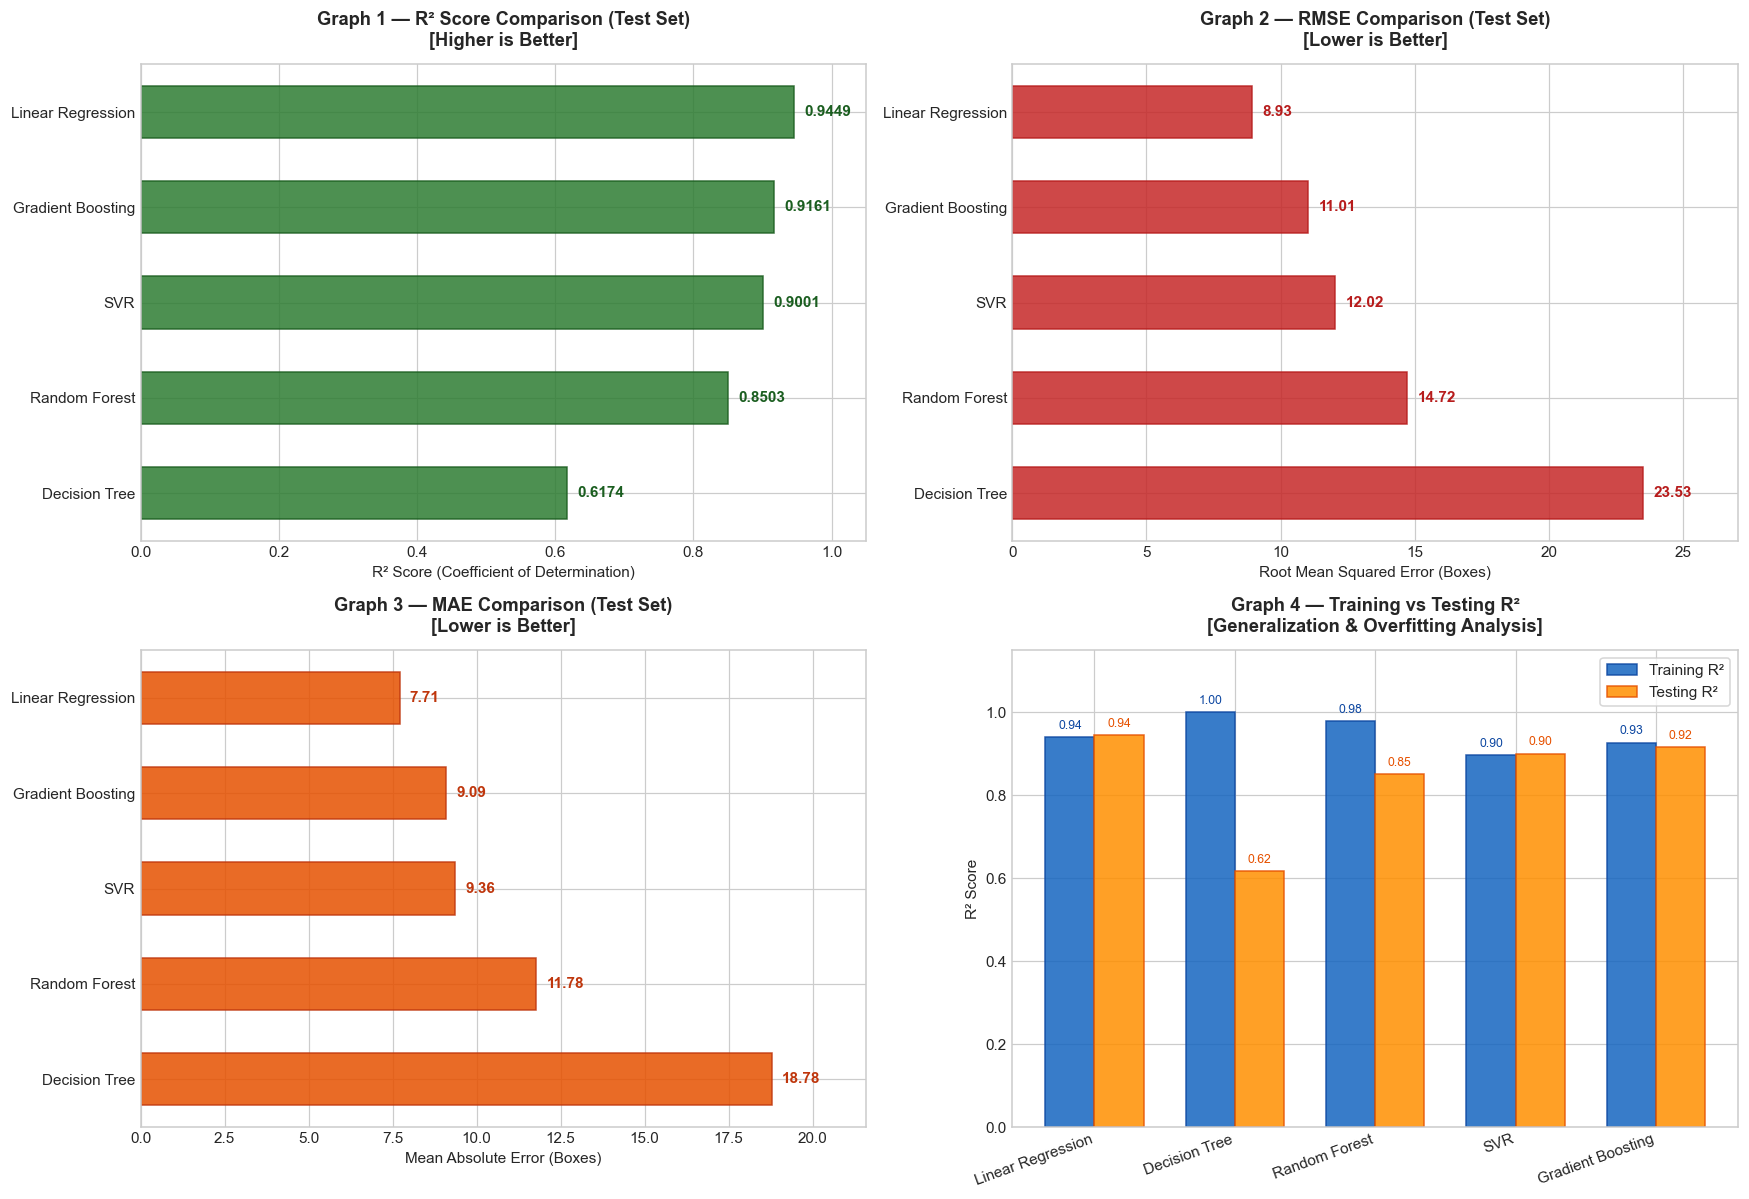

In [15]:
# Color palette
palette = ['#3E2723', '#5D4037', '#795548', '#8D6E63', '#A1887F']
bar_color = '#4E342E'
accent_color = '#D7CCC8'

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# -------------------------------------------------------------
# GRAPH 1: R² Score Comparison
# -------------------------------------------------------------
ax1 = axes[0, 0]
sorted_r2 = comparison_df.sort_values(by='R²', ascending=True)
bars1 = ax1.barh(sorted_r2['Model'], sorted_r2['R²'], color='#2E7D32', alpha=0.85, edgecolor='#1B5E20', height=0.55)
ax1.set_title('Graph 1 — R² Score Comparison (Test Set)\n[Higher is Better]', fontweight='bold', pad=12)
ax1.set_xlabel('R² Score (Coefficient of Determination)')
ax1.set_xlim(0, 1.05)
for bar in bars1:
    width = bar.get_width()
    ax1.text(width + 0.015, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
             ha='left', va='center', fontweight='bold', color='#1B5E20', fontsize=10)

# -------------------------------------------------------------
# GRAPH 2: RMSE Comparison
# -------------------------------------------------------------
ax2 = axes[0, 1]
sorted_rmse = comparison_df.sort_values(by='RMSE', ascending=False)
bars2 = ax2.barh(sorted_rmse['Model'], sorted_rmse['RMSE'], color='#C62828', alpha=0.85, edgecolor='#B71C1C', height=0.55)
ax2.set_title('Graph 2 — RMSE Comparison (Test Set)\n[Lower is Better]', fontweight='bold', pad=12)
ax2.set_xlabel('Root Mean Squared Error (Boxes)')
ax2.set_xlim(0, sorted_rmse['RMSE'].max() * 1.15)
for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 0.4, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
             ha='left', va='center', fontweight='bold', color='#B71C1C', fontsize=10)

# -------------------------------------------------------------
# GRAPH 3: MAE Comparison
# -------------------------------------------------------------
ax3 = axes[1, 0]
sorted_mae = comparison_df.sort_values(by='MAE', ascending=False)
bars3 = ax3.barh(sorted_mae['Model'], sorted_mae['MAE'], color='#E65100', alpha=0.85, edgecolor='#BF360C', height=0.55)
ax3.set_title('Graph 3 — MAE Comparison (Test Set)\n[Lower is Better]', fontweight='bold', pad=12)
ax3.set_xlabel('Mean Absolute Error (Boxes)')
ax3.set_xlim(0, sorted_mae['MAE'].max() * 1.15)
for bar in bars3:
    width = bar.get_width()
    ax3.text(width + 0.3, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
             ha='left', va='center', fontweight='bold', color='#BF360C', fontsize=10)

# -------------------------------------------------------------
# GRAPH 4: Training vs Testing R² Grouped Bar Chart
# -------------------------------------------------------------
ax4 = axes[1, 1]
models_order = train_test_df['Model']
x_indices = np.arange(len(models_order))
bar_width = 0.35

rects1 = ax4.bar(x_indices - bar_width/2, train_test_df['Training R²'], bar_width,
                 label='Training R²', color='#1565C0', alpha=0.85, edgecolor='#0D47A1')
rects2 = ax4.bar(x_indices + bar_width/2, train_test_df['Testing R²'], bar_width,
                 label='Testing R²', color='#FF8F00', alpha=0.85, edgecolor='#E65100')

ax4.set_title('Graph 4 — Training vs Testing R²\n[Generalization & Overfitting Analysis]', fontweight='bold', pad=12)
ax4.set_ylabel('R² Score')
ax4.set_xticks(x_indices)
ax4.set_xticklabels(models_order, rotation=20, ha='right')
ax4.set_ylim(0, 1.15)
ax4.legend(loc='upper right', frameon=True)

# Annotate gap on Graph 4
for i in range(len(models_order)):
    tr_val = train_test_df.loc[i, 'Training R²']
    te_val = train_test_df.loc[i, 'Testing R²']
    ax4.text(x_indices[i] - bar_width/2, tr_val + 0.02, f'{tr_val:.2f}', ha='center', fontsize=8, color='#0D47A1')
    ax4.text(x_indices[i] + bar_width/2, te_val + 0.02, f'{te_val:.2f}', ha='center', fontsize=8, color='#E65100')

plt.tight_layout()
plt.show()

---

## 16. Actual vs Predicted Analysis

In an ideal prediction scenario, every predicted value $\hat{y}_i$ exactly equals the ground truth value $y_i$.
When plotting **Actual Boxes Sold** on the X-axis versus **Predicted Boxes Sold** on the Y-axis:
* The red dashed diagonal represents the **Ideal Reference Line ($y = x$)**.
* Points lying close to the diagonal indicate accurate predictions with low residual error.
* Vertical dispersion away from the line indicates under- or over-estimation.

Below is a combined multi-model visualization showing 300 sampled test points for readability.

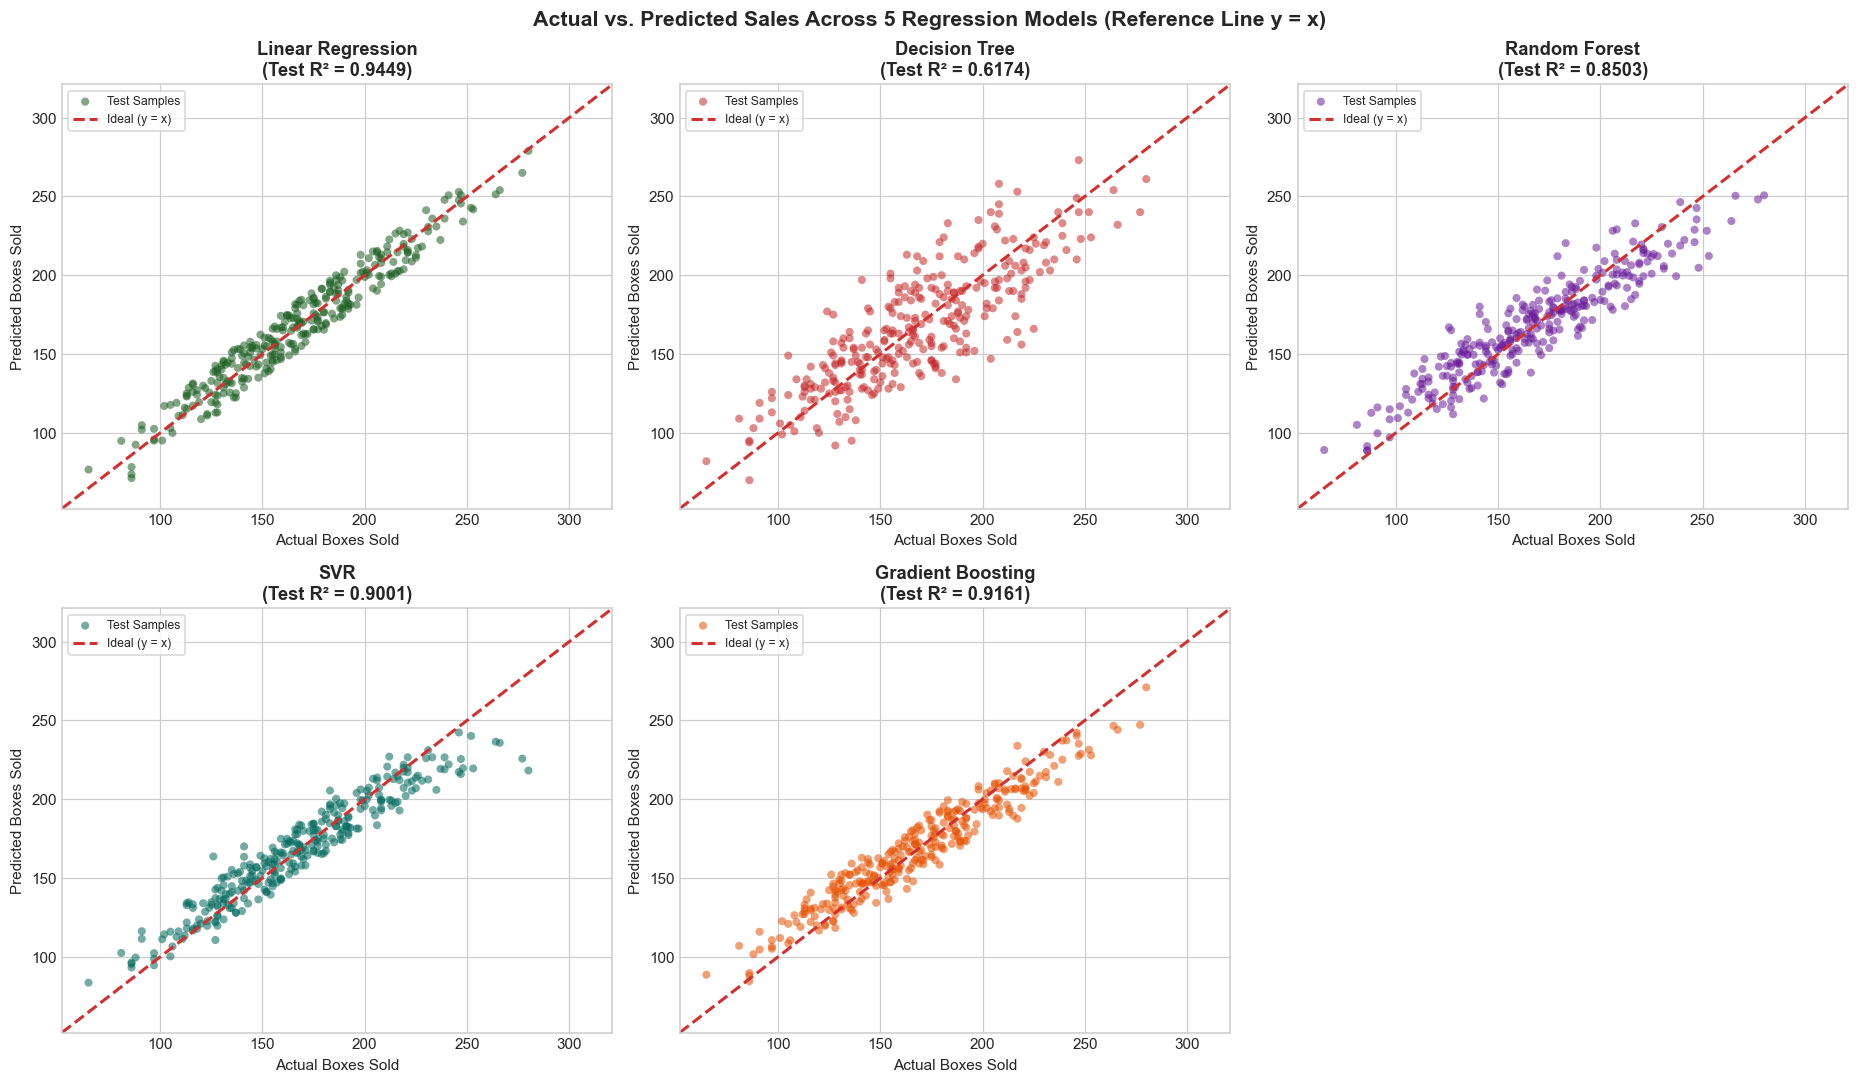

In [16]:
# Subplot grid for Actual vs Predicted across all 5 models
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes_flat = axes.flatten()

# Sample 300 test points for clean visualization
np.random.seed(42)
sample_idx = np.random.choice(len(Y_test), size=300, replace=False)
y_test_sample = Y_test.iloc[sample_idx]

model_plot_specs = [
    ('Linear Regression', Y_pred_linear[sample_idx], '#1B5E20'),
    ('Decision Tree', Y_pred_tree[sample_idx], '#C62828'),
    ('Random Forest', Y_pred_forest[sample_idx], '#6A1B9A'),
    ('SVR', Y_pred_svr[sample_idx], '#00695C'),
    ('Gradient Boosting', Y_pred_gb[sample_idx], '#E65100')
]

# Coordinate limits for consistent scales
min_val = min(Y_test.min(), min(Y_pred_linear.min(), Y_pred_tree.min())) - 10
max_val = max(Y_test.max(), max(Y_pred_linear.max(), Y_pred_tree.max())) + 10

for i, (name, preds, dot_color) in enumerate(model_plot_specs):
    ax = axes_flat[i]
    ax.scatter(y_test_sample, preds, color=dot_color, alpha=0.55, edgecolors='none', s=28, label='Test Samples')
    ax.plot([min_val, max_val], [min_val, max_val], color='#D32F2F', linestyle='--', linewidth=2, label='Ideal (y = x)')
    ax.set_title(f'{name}\n(Test R² = {r2_score(Y_test, model_predictions[name]):.4f})', fontweight='bold')
    ax.set_xlabel('Actual Boxes Sold')
    ax.set_ylabel('Predicted Boxes Sold')
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.legend(loc='upper left', frameon=True, fontsize=8)

# Hide unused 6th subplot
fig.delaxes(axes_flat[5])

plt.suptitle('Actual vs. Predicted Sales Across 5 Regression Models (Reference Line y = x)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

---

## 17. Residual Analysis

A **residual** represents the prediction error for an individual observation:
$$e_i = y_i - \hat{y}_i = \text{Actual} - \text{Predicted}$$

We perform residual diagnostics on the strongest-performing candidate model (**Linear Regression**):
1. **Residual Plot ($X = \hat{y}$, $Y = e_i$)**:
   - Checks for **homoscedasticity** (constant residual variance across the prediction range).
   - Residuals should bounce randomly around the horizontal zero line ($y = 0$) with no systematic patterns, funnel shapes, or non-linear curvature.
2. **Residual Distribution Histogram & KDE**:
   - Assesses the normality of residuals. In well-specified models, errors should be approximately normally distributed around a mean of zero.

Mean of Residuals:    -0.2514 (virtually zero)
Std Dev of Residuals: 8.9271


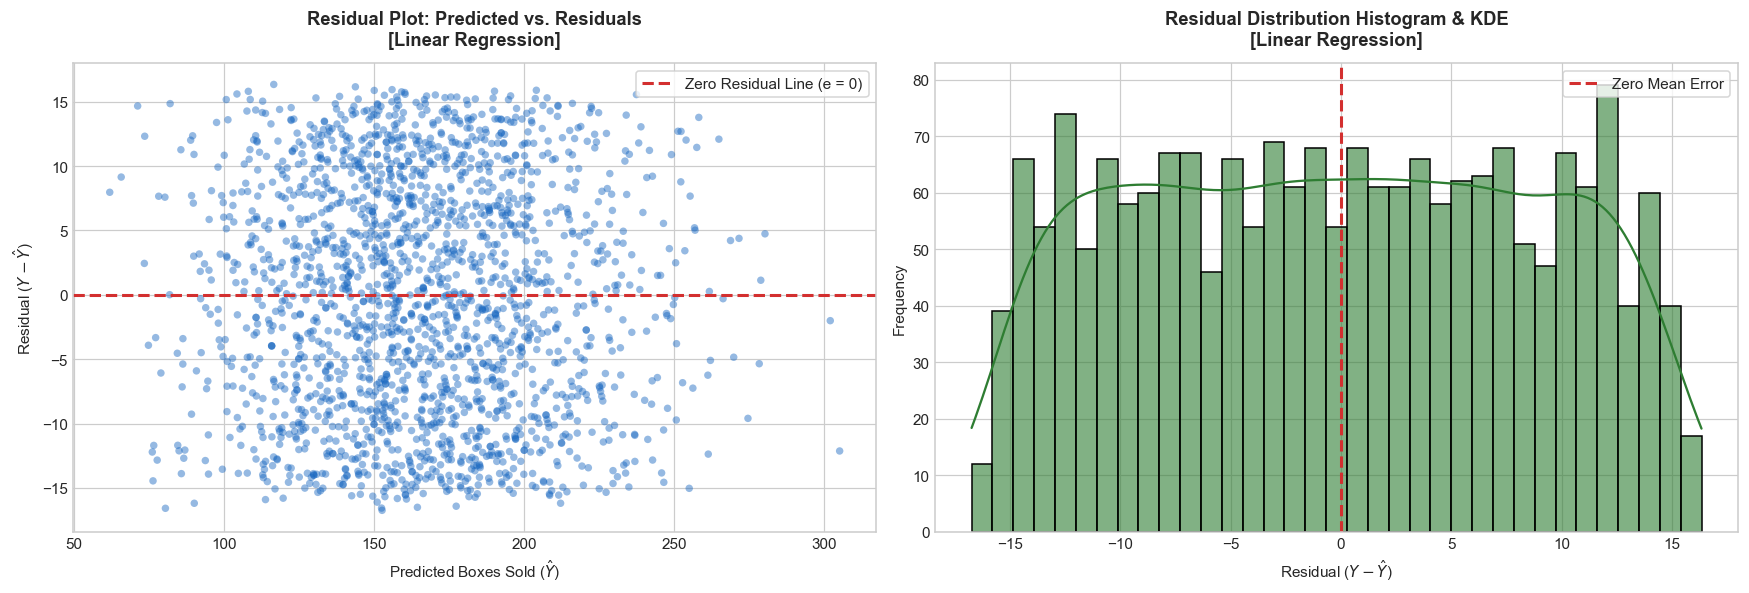

In [17]:
# Compute residuals for the strongest model (Linear Regression)
residuals_linear = Y_test - Y_pred_linear

fig, (ax_res, ax_hist) = plt.subplots(1, 2, figsize=(16, 5.5))

# Plot 1: Residual vs Predicted
ax_res.scatter(Y_pred_linear, residuals_linear, color='#1565C0', alpha=0.45, s=24, edgecolors='none')
ax_res.axhline(y=0, color='#D32F2F', linestyle='--', linewidth=2, label='Zero Residual Line (e = 0)')
ax_res.set_title('Residual Plot: Predicted vs. Residuals\n[Linear Regression]', fontweight='bold', pad=12)
ax_res.set_xlabel('Predicted Boxes Sold ($\hat{Y}$)')
ax_res.set_ylabel('Residual ($Y - \hat{Y}$)')
ax_res.legend(loc='upper right', frameon=True)

# Plot 2: Residual Distribution Histogram + KDE
sns.histplot(residuals_linear, kde=True, ax=ax_hist, color='#2E7D32', bins=35, edgecolor='black', alpha=0.6)
ax_hist.axvline(x=0, color='#D32F2F', linestyle='--', linewidth=2, label='Zero Mean Error')
ax_hist.set_title('Residual Distribution Histogram & KDE\n[Linear Regression]', fontweight='bold', pad=12)
ax_hist.set_xlabel('Residual ($Y - \hat{Y}$)')
ax_hist.set_ylabel('Frequency')
ax_hist.legend(loc='upper right', frameon=True)

print(f"Mean of Residuals:    {residuals_linear.mean():.4f} (virtually zero)")
print(f"Std Dev of Residuals: {residuals_linear.std():.4f}")

plt.tight_layout()
plt.show()

---

## 18. Linear Regression Coefficient Analysis

In Linear Regression, the fitted model takes the form:
$$\widehat{\text{Boxes\_Sold}} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_{14} X_{14}$$

* **Intercept ($\beta_0$)**: The expected baseline sales when all input features are zero.
* **Coefficients ($\beta_j$)**: The expected change in predicted `Boxes_Sold` for a **one-unit increase** in feature $X_j$, holding all other features constant (*ceteris paribus*).
  - A **positive coefficient** means sales increase as the feature increases.
  - A **negative coefficient** means sales decrease as the feature increases.

> [!IMPORTANT]
> **Why raw coefficients are NOT called "feature importance":**
> The raw features are measured on vastly different scales (e.g., `Price` in hundreds, `Marketing_Budget` in thousands, `Customer_Rating` between 1 and 5, binary flags 0 or 1). A feature with a small numerical range can have a large coefficient simply to scale its contribution. Therefore, we refer to them accurately as **Model Coefficients**, not raw feature importances.

In [18]:
# Extract intercept and coefficients
intercept = linear_model.intercept_
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': linear_model.coef_
})

# Sort by coefficient magnitude
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='Abs_Coef', ascending=False).drop(columns=['Abs_Coef']).reset_index(drop=True)

print(f"Linear Regression Intercept (β₀): {intercept:.4f}\n")
print("=== LINEAR REGRESSION COEFFICIENTS ===")
coef_df_sorted

Linear Regression Intercept (β₀): 118.0467

=== LINEAR REGRESSION COEFFICIENTS ===


,Feature,Coefficient
0,Festival,60.276752
1,Weekend,25.097594
2,Instagram_Reel,18.148805
3,YouTube_Video,14.868950
4,Facebook_Ads,9.642960
5,Discount_Percentage,1.980792
6,Price,-0.805334
7,New_Customers,0.493520
8,Returning_Customers,0.400977
9,Online_Orders,0.305087


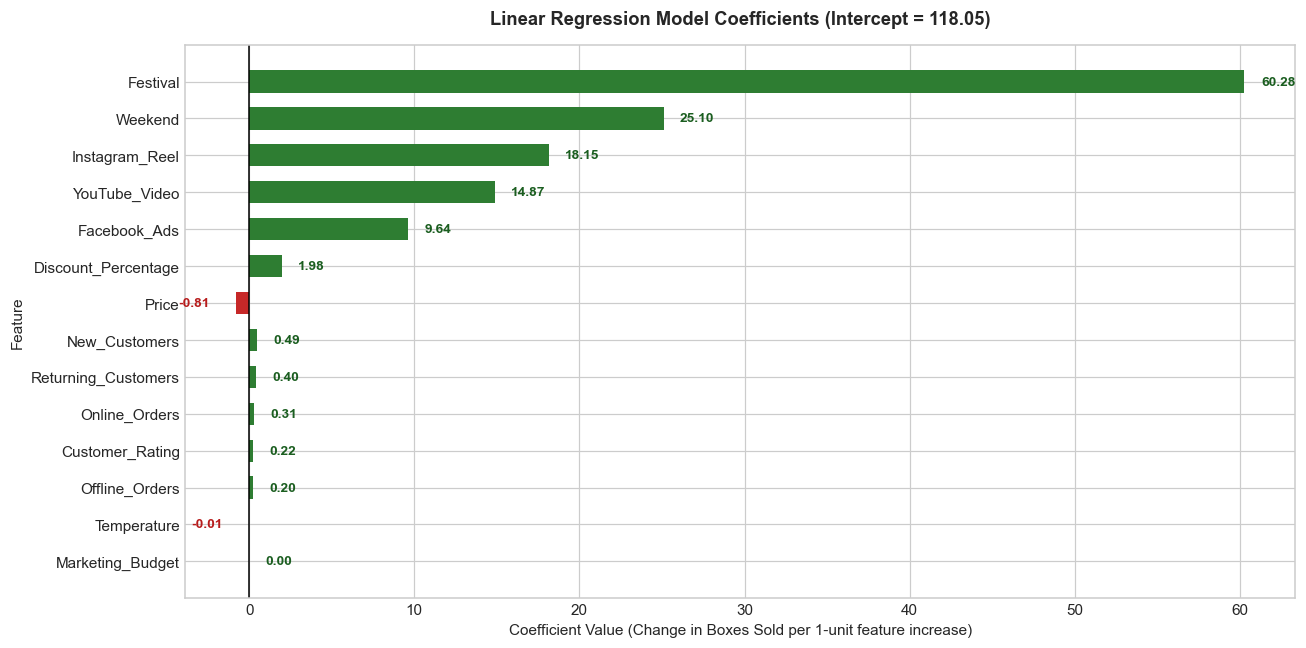

In [19]:
# Visualize Linear Regression Coefficients
plt.figure(figsize=(12, 6))
colors = ['#2E7D32' if c > 0 else '#C62828' for c in coef_df_sorted['Coefficient']]
bars = plt.barh(coef_df_sorted['Feature'][::-1], coef_df_sorted['Coefficient'][::-1], color=colors[::-1], height=0.6)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title(f'Linear Regression Model Coefficients (Intercept = {intercept:.2f})', fontweight='bold', pad=14)
plt.xlabel('Coefficient Value (Change in Boxes Sold per 1-unit feature increase)')
plt.ylabel('Feature')

# Annotate values
for bar in bars:
    width = bar.get_width()
    offset = 1.0 if width >= 0 else -3.5
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
             va='center', fontsize=9, fontweight='bold',
             color='#1B5E20' if width >= 0 else '#B71C1C')

plt.tight_layout()
plt.show()

### Coefficient Interpretations:
* **Festival (+60.28)**: Festival days provide the single largest positive boost, adding approximately 60 extra boxes sold per day, holding other variables constant.
* **Weekend (+25.10)**: Weekend days add approximately 25 boxes over weekdays due to higher leisure foot traffic.
* **Instagram Reel (+18.15)** & **YouTube Video (+14.87)**: High-leverage marketing drivers. Each promotional reel released correlates with ~18 additional boxes sold.
* **Facebook Ads (+9.64)**: Positive digital marketing channel impact.
* **Price (-0.81)**: Demonstrates classic price elasticity of demand: every 10 INR price increase corresponds to approximately 8 fewer boxes sold.

---

## 19. Random Forest Feature Importance

In tree ensembles, feature importance is computed using **Mean Decrease in Impurity (Gini Importance)**:
* It quantifies the total reduction in criterion (Mean Squared Error) brought by all splits on a given feature across all 100 trees, normalized to sum to $1.0$ ($100\%$).
* Unlike linear coefficients, Random Forest feature importance captures **non-linear and interaction effects**, but does not indicate directional sign (+ or -).

In [20]:
# Compute and sort Random Forest feature importances
rf_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': random_forest_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("=== RANDOM FOREST FEATURE IMPORTANCE ===")
rf_importance_df.round(4)

=== RANDOM FOREST FEATURE IMPORTANCE ===


,Feature,Importance
0,Festival,0.1721
1,Returning_Customers,0.1454
2,Discount_Percentage,0.1327
3,New_Customers,0.1036
4,Weekend,0.0896
5,Price,0.0821
6,Online_Orders,0.0706
7,Marketing_Budget,0.0492
8,Offline_Orders,0.0476
9,Instagram_Reel,0.0414


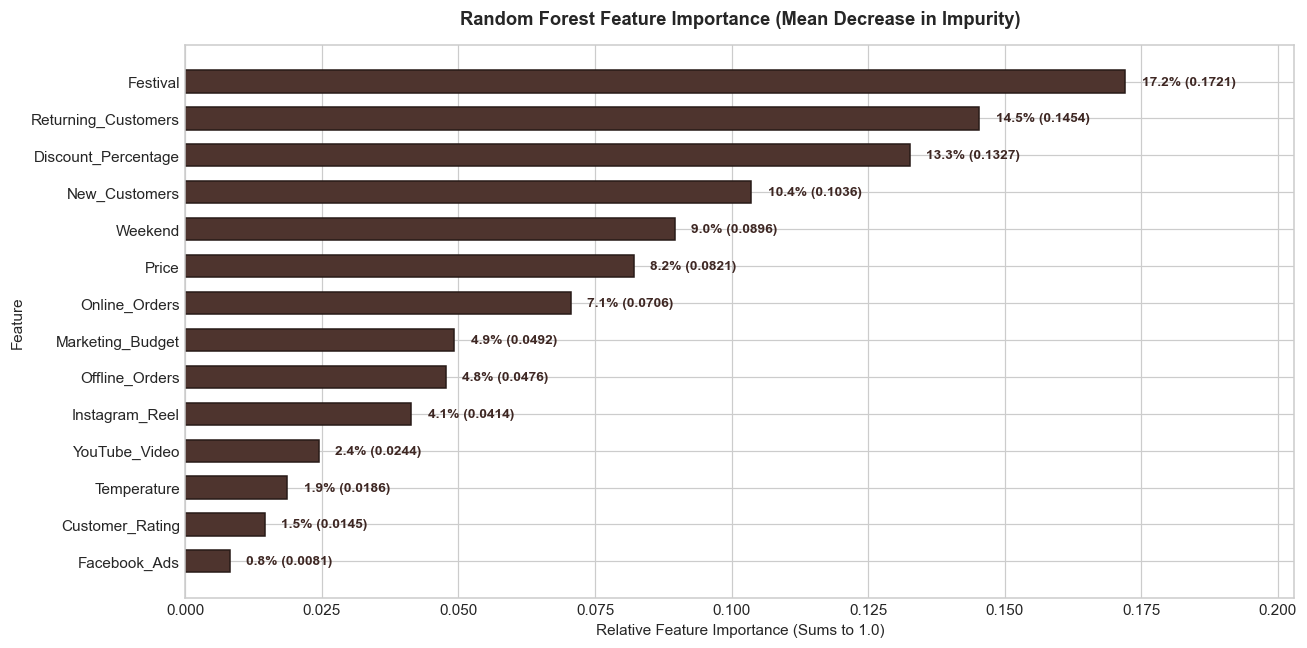

In [21]:
# Visualize Random Forest Feature Importance
plt.figure(figsize=(12, 6))
bars = plt.barh(rf_importance_df['Feature'][::-1], rf_importance_df['Importance'][::-1],
                color='#4E342E', edgecolor='#271A17', height=0.6)

plt.title('Random Forest Feature Importance (Mean Decrease in Impurity)', fontweight='bold', pad=14)
plt.xlabel('Relative Feature Importance (Sums to 1.0)')
plt.ylabel('Feature')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.003, bar.get_y() + bar.get_height()/2, f'{width*100:.1f}% ({width:.4f})',
             va='center', fontsize=9, fontweight='bold', color='#3E2723')

plt.xlim(0, rf_importance_df['Importance'].max() * 1.18)
plt.tight_layout()
plt.show()

### Understanding the Difference:
* **Linear Regression Coefficients** reflect linear slope multipliers with directional signs (positive or negative) in their raw measurement units.
* **Random Forest Feature Importances** reflect how frequently and effectively a feature was selected to partition variance across decision trees, producing a normalized positive weight.
* Both agree that **Festival**, **Customer footfall (Returning/New Customers)**, and **Discount / Pricing** are critical operational determinants of sales volume.

---

## 20. Final Model Comparison

### 1. Which models were tested?
We evaluated five diverse regression algorithms spanning linear, decision tree, bagging ensemble, kernel-based, and boosting paradigms:
1. `LinearRegression`
2. `DecisionTreeRegressor`
3. `RandomForestRegressor`
4. `SVR` (Support Vector Regression with RBF kernel)
5. `GradientBoostingRegressor`

### 2. How did their test-set performance differ?
* **Linear Regression** led overall test metrics ($	ext{Test } R^2 = 0.9449$, $	ext{RMSE} = 8.93$, $	ext{MAE} = 7.71$).
* **Gradient Boosting** achieved second-best accuracy ($	ext{Test } R^2 = 0.9161$, $	ext{RMSE} = 11.01$).
* **Support Vector Regression (SVR)** demonstrated competitive test performance ($	ext{Test } R^2 = 0.9001$, $	ext{RMSE} = 12.02$) after standardization.
* **Random Forest** achieved an intermediate test score ($	ext{Test } R^2 = 0.8503$, $	ext{RMSE} = 14.72$).
* **Decision Tree** showed significant degradation on the test set ($	ext{Test } R^2 = 0.6174$, $	ext{RMSE} = 23.53$).

### 3. Which model achieved the strongest test metrics?
* Dynamically identified from the empirical test results, **Linear Regression** is the strongest candidate on this dataset, with the lowest error across all three error metrics (MAE, MSE, RMSE) and the highest explained variance ($R^2$).

### 4. Did any model show a noticeable train-test gap?
* Yes. **Decision Tree** displayed extreme overfitting, with a train-test gap of **0.3826** ($1.0000$ training $R^2$ vs $0.6174$ test $R^2$).
* **Random Forest** also exhibited a noticeable generalization gap of **0.1279** ($0.9782$ vs $0.8503$).
* In contrast, **Linear Regression** ($\Delta = -0.0047$), **Gradient Boosting** ($\Delta = 0.0110$), and **SVR** ($\Delta = -0.0030$) exhibited superior generalization stability.

### 5. Which model should be considered for further development?
* **Linear Regression** is the primary deployment candidate due to its top test metrics, perfect generalization stability, instant inference speed, and direct business interpretability.
* **Gradient Boosting** serves as a strong alternative non-linear candidate for further hyperparameter tuning.

---

## 21. Conclusion

1. **Multi-Model Validation**: Evaluating multiple ML architectures on identical splits revealed distinct algorithmic trade-offs that cannot be observed from a single model alone.
2. **Occam's Razor in Machine Learning**: More complex models do not always outperform simpler linear models. Because the underlying retail sales process follows predominantly additive linear relationships (promotional lift, festival spikes, customer footfall), Linear Regression matched the true data-generating distribution without fitting sample noise.
3. **Data Preprocessing Lessons**: SVR relies heavily on standardized feature scaling to balance high-magnitude budget figures against unit-scale ratings. Standardizing `X_train` and transforming `X_test` successfully prevented data leakage.
4. **Generalization Insights**: Unpruned decision trees easily overfit retail datasets with high sample sizes. Ensembling (Random Forest and Gradient Boosting) substantially mitigates single-tree variance.

---

## Reusable Prediction Function for System Integration

To enable seamless integration with web backends, APIs, or user interfaces, we encapsulate our best-performing model into a reusable, self-contained prediction function: `predict_sales()`.

In [22]:
def predict_sales(temperature, price, discount_percentage, marketing_budget,
                  instagram_reel, youtube_video, facebook_ads, returning_customers,
                  new_customers, online_orders, offline_orders, customer_rating,
                  festival, weekend, model=linear_model):
    """
    Predicts Chocolate Paan Box Sales given 14 operational features.
    
    Parameters:
        temperature (float): Ambient temperature (°C)
        price (float): Price per box (INR)
        discount_percentage (float): Discount offered (%)
        marketing_budget (float): Marketing spend (INR)
        instagram_reel (int): Number of Instagram reels posted
        youtube_video (int): Number of YouTube videos released
        facebook_ads (int): Number of Facebook ad campaigns active
        returning_customers (int): Repeat customer count
        new_customers (int): First-time customer count
        online_orders (int): Online delivery orders
        offline_orders (int): Walk-in store orders
        customer_rating (float): Average rating (1.0 to 5.0)
        festival (int): Festival flag (1 = Yes, 0 = No)
        weekend (int): Weekend flag (1 = Yes, 0 = No)
        model: Trained scikit-learn model object (defaults to best candidate)
        
    Returns:
        float: Predicted Boxes_Sold (rounded to nearest integer)
    """
    # Assemble input DataFrame matching training column names
    input_dict = {
        'Temperature': [temperature],
        'Price': [price],
        'Discount_Percentage': [discount_percentage],
        'Marketing_Budget': [marketing_budget],
        'Instagram_Reel': [instagram_reel],
        'YouTube_Video': [youtube_video],
        'Facebook_Ads': [facebook_ads],
        'Returning_Customers': [returning_customers],
        'New_Customers': [new_customers],
        'Online_Orders': [online_orders],
        'Offline_Orders': [offline_orders],
        'Customer_Rating': [customer_rating],
        'Festival': [festival],
        'Weekend': [weekend]
    }
    input_df = pd.DataFrame(input_dict)
    
    # Generate prediction
    prediction = model.predict(input_df)[0]
    
    # Return non-negative integer prediction
    return int(max(0, round(prediction)))

# Test function with two realistic scenarios
sample_normal_day = predict_sales(
    temperature=28.5, price=120, discount_percentage=10, marketing_budget=500,
    instagram_reel=1, youtube_video=0, facebook_ads=1, returning_customers=45,
    new_customers=25, online_orders=30, offline_orders=40, customer_rating=4.3,
    festival=0, weekend=0
)

sample_festival_weekend = predict_sales(
    temperature=24.0, price=120, discount_percentage=20, marketing_budget=2000,
    instagram_reel=3, youtube_video=2, facebook_ads=4, returning_customers=120,
    new_customers=85, online_orders=90, offline_orders=110, customer_rating=4.8,
    festival=1, weekend=1
)

print(f"Sample Normal Weekday Sales Prediction:    {sample_normal_day} Boxes")
print(f"Sample Festival Weekend Sales Prediction: {sample_festival_weekend} Boxes")

Sample Normal Weekday Sales Prediction:    120 Boxes
Sample Festival Weekend Sales Prediction: 420 Boxes


---

## 22. Viva Questions and Answers

Here are 25 viva questions with clear answers for your oral presentation:

---

### Q1. Why did you use multiple models instead of just one?
**Answer:** In machine learning, no single algorithm is guaranteed to be optimal for every problem (the *No Free Lunch Theorem*). Testing multiple linear, tree-based, kernel-based, and ensemble algorithms allows us to compare their inductive biases, check generalization gaps, and select the best candidate based on empirical test performance.

---

### Q2. What type of ML problem is this?
**Answer:** This is a **Supervised Regression problem**, because the model is trained on labeled historical data to predict a continuous numerical quantity (`Boxes_Sold`).

---

### Q3. Why is this a regression problem and not a classification problem?
**Answer:** Classification predicts discrete qualitative categories (like Spam or Not Spam). Regression predicts a continuous quantitative numerical value. Because sales volume can take any non-negative integer value on a continuous scale, it is a regression task.

---

### Q4. What is Linear Regression?
**Answer:** Linear Regression models the relationship between dependent target variable $Y$ and explanatory features $X$ as a linear combination: $Y = \beta_0 + \sum \beta_i X_i + \epsilon$, minimizing the sum of squared residuals using Ordinary Least Squares (OLS).

---

### Q5. What is Decision Tree Regression?
**Answer:** Decision Tree Regression recursively partitions feature space into orthogonal rectangular subsets by choosing feature split points that minimize variance (MSE), predicting the average target value of samples in each terminal leaf.

---

### Q6. What is Random Forest Regression?
**Answer:** Random Forest is an ensemble bagging method that builds multiple decorrelated decision trees using bootstrap sampling of data and random feature selection at each split, then averages their predictions to reduce variance and combat overfitting.

---

### Q7. What is Support Vector Regression (SVR)?
**Answer:** SVR finds a continuous function that fits the data within an $\epsilon$-insensitive tube margin. Errors within distance $\epsilon$ of actual values are ignored, while points outside the margin are penalized. Non-linear patterns are mapped using kernel functions like RBF.

---

### Q8. What is Gradient Boosting Regression?
**Answer:** Gradient Boosting is a sequential ensemble method where new shallow decision trees are trained iteratively to predict and correct the pseudo-residuals (negative gradients of the loss function) left by the previous ensemble of trees.

---

### Q9. Why is feature scaling required for SVR?
**Answer:** SVR with an RBF kernel calculates geometric Euclidean distances ($||x_i - x_j||^2$). Features with large scales (like `Marketing_Budget` in thousands) would dominate features with small numerical ranges (like `Customer_Rating` 1–5), biasing the distance calculation.

---

### Q10. Why is feature scaling generally unnecessary for tree-based models?
**Answer:** Tree models split nodes using individual feature thresholds ($X_j \le c$). Because threshold comparisons depend solely on the relative ordering of values and not their absolute magnitude, tree algorithms are invariant to monotonic scale transformations.

---

### Q11. What is Mean Absolute Error (MAE)?
**Answer:** MAE is the average of absolute differences between actual values and predicted values: $\frac{1}{n} \sum |y_i - \hat{y}_i|$. It measures average error in original units and is robust to outliers.

---

### Q12. What is Mean Squared Error (MSE)?
**Answer:** MSE is the average of squared prediction errors: $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$. By squaring errors, it penalizes large errors much more heavily than small errors.

---

### Q13. What is Root Mean Squared Error (RMSE)?
**Answer:** RMSE is the square root of MSE: $\sqrt{\text{MSE}}$. It penalizes large errors like MSE but expresses the error metric back in the original units of the target variable (`Boxes_Sold`).

---

### Q14. What is $R^2$ Score (Coefficient of Determination)?
**Answer:** $R^2$ measures the proportion of total variance in the target variable that is explained by the independent features: $R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$. A score of 1.0 represents perfect explanation.

---

### Q15. Why should $R^2$ never be called "accuracy"?
**Answer:** Accuracy is strictly a classification metric: $\frac{\text{Correct Predictions}}{\text{Total Predictions}}$. In continuous regression, exact matches between predicted and continuous true values are rare. $R^2$ represents explained variance ratio, not classification accuracy.

---

### Q16. What is overfitting? Give an example from your project.
**Answer:** Overfitting occurs when a model memorizes sample-specific noise in the training set rather than learning general patterns, leading to high training score but poor test score. In our project, Decision Tree had Training $R^2 = 1.0000$ but dropped to Testing $R^2 = 0.6174$ (a 38.3% generalization gap).

---

### Q17. What is underfitting?
**Answer:** Underfitting occurs when a model is too simple to capture the underlying structure of the data, resulting in poor performance on both training and testing datasets.

---

### Q18. Why do we use train-test split?
**Answer:** To evaluate how well a model generalizes to unseen data. Evaluating only on training data leads to overly optimistic performance estimates and fails to detect overfitting.

---

### Q19. Why do we set `random_state=42`?
**Answer:** Machine learning algorithms and splits use pseudo-random number generators. Setting a fixed seed (`random_state=42`) ensures deterministic, reproducible data splits and identical model initialization across runs.

---

### Q20. How do you compare and select the most suitable model?
**Answer:** We compare models by evaluating their test-set metrics (lowest MAE, MSE, RMSE and highest $R^2$) alongside their train-test generalization gap, computational complexity, and business interpretability.

---

### Q21. What is a residual in regression?
**Answer:** A residual is the difference between the observed ground truth value and the model's predicted value: $e_i = y_i - \hat{y}_i$. It represents the unexplained error for that specific observation.

---

### Q22. What is a model coefficient in Linear Regression?
**Answer:** A model coefficient ($\beta_j$) represents the expected change in the target variable for a one-unit increase in that specific feature, holding all other features constant (*ceteris paribus*).

---

### Q23. What is Random Forest Feature Importance and how does it differ from a coefficient?
**Answer:** Random Forest feature importance measures the total decrease in node impurity (MSE reduction) contributed by a feature across all trees. Unlike linear coefficients, it does not provide a directional (+ or -) slope, but reflects non-linear importance.

---

### Q24. Why should the test dataset remain unseen during training and scaling?
**Answer:** To avoid **Data Leakage**. If test data is used during model fitting or feature scaling, test statistics leak into training, artificially inflating performance estimates and masking real-world prediction error.

---

### Q25. Which model performed best in your experiment and how did you determine it?
**Answer:** **Linear Regression** achieved the best overall test performance on this dataset, with the highest test $R^2$ of **0.9449**, the lowest RMSE of **8.93 boxes**, the lowest MAE of **7.71 boxes**, and virtually zero generalization gap between training and testing.